<a href="https://colab.research.google.com/github/ayunda-mp/Iris_Sampling_Bootstrap/blob/main/Tugas_Pre_prosesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HUMAN DEVELOPMENT INDEX (HDI)**

Data yang digunakan dalam proses ini berasal dari laporan Human Development Index (HDI) oleh UNDP (1990–2017). Data ini mencakup peringkat HDI (HDI Rank), nama negara (Country), dan skor indeks pembangunan manusia tahunan.
Tujuannya adalah untuk menyiapkan dataset yang valid secara statistik guna menganalisis tren pembangunan manusia global. Dengan melakukan pra-pemrosesan ini, data yang tadinya hanya berupa tabel laporan diubah menjadi Data Panel yang siap digunakan untuk model regresi atau machine learning untuk melihat hubungan antar variabel.

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Tahap 1 - Tahap Loading dan Inspeksi Data
Memuat file CSV ke dalam sistem. Fungsi df.info() sangat penting karena memberikan "rontgen" awal terhadap kesehatan data. Kita bisa melihat kolom mana yang memiliki banyak nilai kosong (missing values) dan memastikan tipe datanya (apakah angka atau teks). Tanpa inspeksi ini, kita berisiko mengolah data yang salah format.

In [ ]:
file_name = '/content/Human Development Index.csv'
df_hdi = pd.read_csv(file_name)
print(df_hdi.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 30 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   HDI Rank  189 non-null    int64  
 1   Country   189 non-null    object 
 2   1990      142 non-null    float64
 3   1991      143 non-null    float64
 4   1992      140 non-null    float64
 5   1993      143 non-null    float64
 6   1994      143 non-null    float64
 7   1995      147 non-null    float64
 8   1996      147 non-null    float64
 9   1997      147 non-null    float64
 10  1998      147 non-null    float64
 11  1999      150 non-null    float64
 12  2000      172 non-null    float64
 13  2001      172 non-null    float64
 14  2002      174 non-null    float64
 15  2003      176 non-null    float64
 16  2004      179 non-null    float64
 17  2005      186 non-null    float64
 18  2006      186 non-null    float64
 19  2007      186 non-null    float64
 20  2008      186 non-null    float6

### Tahap 2 - Pembersihan Data Awal (Cleaning)
Kode dropna(subset=['Country', '2017']) berfungsi sebagai filter kualitas.
*   Country : Menghapus baris tanpa nama negara karena data tanpa identitas tidak dapat dianalisis.
*   2017 : Menghapus negara yang tidak memiliki data di tahun terbaru. Menurut buku Sharma, data terbaru adalah indikator paling relevan untuk memahami kondisi saat ini. Jika tahun 2017 saja kosong, kemungkinan besar data historisnya juga tidak reliabel.

In [ ]:
df_clean = df_hdi.dropna(subset=['Country', '2017']).copy()
print(f"\nBaris tersisa: {len(df_clean)}")


Baris tersisa: 189


### Tahap 3 - Deteksi Outlier Awal (Boxplot)
Sebelum data diubah, kita melihat sebaran aslinya melalui Boxplot. Grafik ini membantu kita mengidentifikasi nilai ekstrem (misal negara dengan pembangunan sangat rendah) yang bisa mengganggu hasil rata-rata. Ini adalah tahap "kenali datamu" sebelum melakukan manipulasi matematika lebih lanjut.


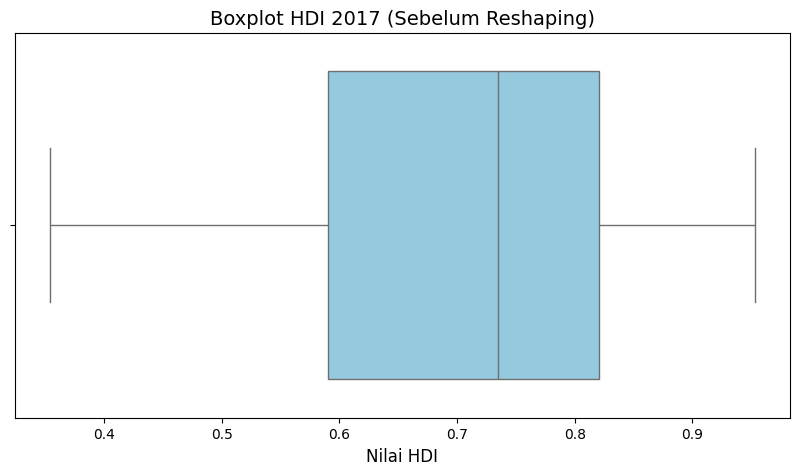

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['2017'], color='skyblue')
plt.title('Boxplot HDI 2017 (Sebelum Reshaping)', fontsize=14)
plt.xlabel('Nilai HDI', fontsize=12)
plt.savefig('hdi_initial_boxplot_2017.png')

Garis di dalam kotak menunjukkan nilai tengah HDI dunia tahun 2017 (sekitar 0.735). Karena garis ini berada agak ke kanan dalam kotak, ini menandakan bahwa mayoritas negara cenderung memiliki skor HDI yang cukup tinggi. Area kotak menunjukkan sebaran 50% negara di dunia. Bagian kiri kotak (Q1) berada di angka sekitar 0.6, dan bagian kanan (Q3) di angka sekitar 0.85. Artinya, separuh negara di dunia memiliki skor pembangunan manusia antara 0.6 hingga 0.85. Garis yang memanjang ke kiri dan kanan menunjukkan rentang data yang masih dianggap "normal" atau tidak ekstrem.

### Tahap 4 - Transformasi Bentuk Data (Reshaping/Melt)
Data asli berbentuk Wide (tahun menyamping) diubah menjadi Long (tahun menurun). Algoritma statistik dan model regresi membutuhkan struktur di mana satu baris mewakili satu kejadian unik (misal: Indonesia tahun 1990). Dengan format Long, kita memiliki kolom Year dan HDI_Value yang rapi. Baris yang masih kosong setelah proses ini juga dihapus agar dataset menjadi "padat".

In [ ]:
year_cols = [str(y) for y in range(1990, 2018)]
df_long = pd.melt(df_clean,
                  id_vars=['HDI Rank', 'Country'],
                  value_vars=year_cols,
                  var_name='Year',
                  value_name='HDI_Value')

df_long = df_long.dropna(subset=['HDI_Value']).copy()
print(f"\nTotal observasi panel: {len(df_long)}")


Total observasi panel: 4757


### Tahap 5 - Standarisasai Nilai ($Z$-Score)
Menggunakan StandardScaler untuk mengubah nilai HDI (0-1) menjadi skor standar ($Z$-score). Nilai baru ini berpusat di angka 0 (sebagai rata-rata dunia). Ini menghilangkan bias skala, sehingga jika nantinya Anda menambahkan variabel lain (seperti PDB), model tidak akan bingung oleh perbedaan satuan angka.

In [ ]:
scaler = StandardScaler()
df_long['HDI_Standardized'] = scaler.fit_transform(df_long[['HDI_Value']])
print(df_long.head())

   HDI Rank     Country  Year  HDI_Value  HDI_Standardized
1        68     Albania  1990      0.645         -0.060750
2        85     Algeria  1990      0.577         -0.471088
6        47   Argentina  1990      0.704          0.295279
7        83     Armenia  1990      0.631         -0.145231
8         3   Australia  1990      0.866          1.272849


Jika sebuah negara memiliki nilai standardized mendekati 0, artinya pembangunan manusia di negara tersebut sama dengan rata-rata dunia. nilai positif menunjukkan negara tersebut berada di atas rata-rata. Semakin besar angkanya, semakin tinggi tingkat pembangunannya dibanding negara lain. nilai negatif menunjukkan negara tersebut berada di bawah rata-rata.

### Tahap 6 - Identifikasi Kelompok Ekstrem
Setelah distandarisasi, kita menyaring negara-negara yang memiliki skor $> +1$ atau $< -1$. Hasil Kode: Terdeteksi 48 negara di kelompok sangat tinggi dan 19 negara di kelompok sangat rendah pada tahun 2017.Tahapan ini bukan hanya soal angka, tapi membantu peneliti mengidentifikasi kelompok negara yang memerlukan perhatian khusus dalam analisis kebijakan.

In [ ]:
df_2017 = df_long[df_long['Year'] == '2017'].copy()
high_outliers = df_2017[df_2017['HDI_Standardized'] > 1]
low_outliers = df_2017[df_2017['HDI_Standardized'] < -1]
print(f"\nHigh (> +1): {len(high_outliers)} negara\nLow (< -1): {len(low_outliers)} negara")


High (> +1): 48 negara
Low (< -1): 19 negara


Terdeteksi 48 negara di kelompok sangat tinggi dan 19 negara di kelompok sangat rendah pada tahun 2017. Tahapan ini bukan hanya soal angka, tapi membantu peneliti mengidentifikasi kelompok negara yang memerlukan perhatian khusus dalam analisis kebijakan.

### Tahap 7 - Visualisasi Distribusi Terstandarisasi
Membuat histogram untuk memvalidasi hasil standarisasi secara visual.

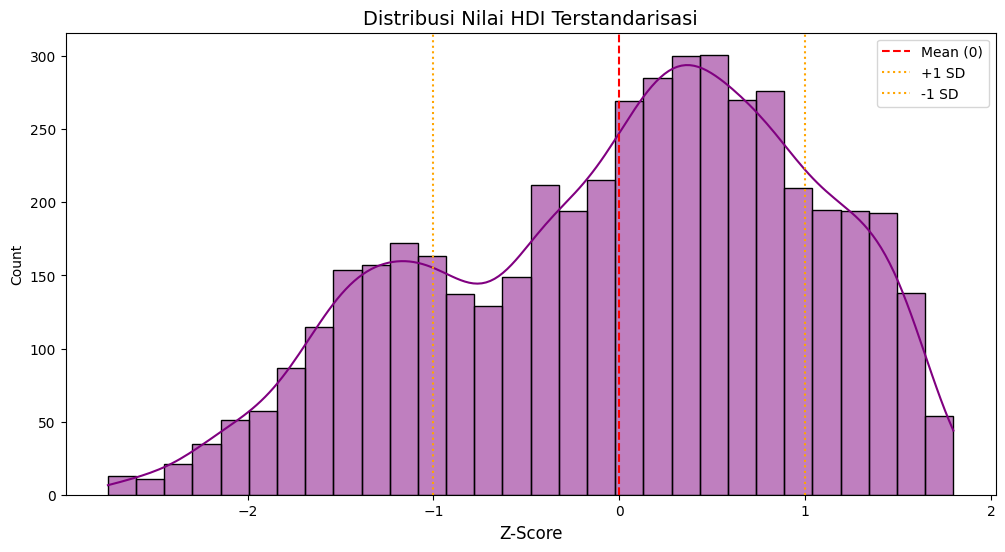

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_long['HDI_Standardized'], kde=True, color='purple', bins=30)
plt.axvline(0, color='red', linestyle='--', label='Mean (0)')
plt.axvline(1, color='orange', linestyle=':', label='+1 SD')
plt.axvline(-1, color='orange', linestyle=':', label='-1 SD')
plt.title('Distribusi Nilai HDI Terstandarisasi', fontsize=14)
plt.xlabel('Z-Score', fontsize=12)
plt.legend()
plt.savefig('hdi_standardized_distribution_new.png')

Garis Merah (0)Membuktikan bahwa pusat data kini berada di rata-rata dunia. Sedangkan Garis Oranye (+/- 1) memberikan batas visual untuk melihat seberapa banyak negara yang berada di area "normal" (tengah) dan seberapa banyak yang menyimpang ke arah ekstrem. Jika kurva terlihat seperti lonceng, maka data tersebut memenuhi syarat untuk uji statistik tingkat lanjut.

### Tahap 8 - Penyimpanan Data Akhir
Data yang sudah melewati semua filter dan transformasi disimpan dalam file hdi_final_standardized.csv. File ini adalah hasil akhir yang sudah "siap pakai"—bersih dari missing values, memiliki struktur panel yang benar, dan sudah memiliki skala standar untuk dihubungkan dengan variabel riset lainnya

In [ ]:
df_long.to_csv('hdi_final_standardized.csv', index=False)

**KESIMPULAN**

Proses pra-pemrosesan ini telah berhasil mentransformasi data mentah yang bersifat statis menjadi dataset saintifik yang valid dan siap digunakan untuk analisis tingkat lanjut, seperti regresi data panel atau machine learning. Melalui tahap Initial Cleaning yang memfilter kolom kritis (Negara dan Tahun 2017), integritas data terjaga dari risiko bias Garbage In, Garbage Out dengan memastikan hanya observasi mutakhir yang diolah. Langkah krusial berupa Reshaping dari format Wide ke Long menghasilkan struktur data panel dinamis dengan total 4.757 observasi, yang memungkinkan pemodelan tren antar waktu dan wilayah secara simultan.


Selain itu, penerapan StandardScaler telah menyamakan "bahasa" angka HDI menjadi skor Z yang berpusat di angka 0, sehingga variabel ini dapat dibandingkan secara adil dengan variabel lain tanpa kendala perbedaan satuan. Secara substantif, hasil visualisasi dan deteksi pencilan membuktikan adanya ketimpangan pembangunan yang nyata, ditandai dengan terdeteksinya 48 negara di kelompok sangat tinggi (> +1 SD) dan 19 negara di kelompok sangat rendah (< -1 SD).